In [1]:
import pandas as pd
from pycaret.classification import *
from pycaret.regression import *
from pycaret.clustering import *
from pycaret.anomaly import *
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("sem tempo2.csv",na_values=['', ' ', 'Sem resposta'])



In [3]:

#one_hot_encoded_df = pd.get_dummies(df, columns=['Você sofreu algum tipo de preconceito ou violência durante o curso relativo a:'])

#pd.set_option('display.max_rows', None)

#one_hot_encoded_df.to_csv('one_hot_encoded.csv', index=False)


#display(one_hot_encoded_df)


In [4]:
from pycaret.classification import *


# Configurar o ambiente de classificação (setup)
clf_setup = setup(data=df, 
                  target='Já pensou em trancar disciplinas, período ou abandonar o curso? Se sim, por que?',  #coluna-alvo
                  session_id=123)  # Usado para garantir reprodutibilidade


,Description,Value
0,Session id,123
1,Target,"Já pensou em trancar disciplinas, período ou abandonar o curso? Se sim, por que?"
2,Target type,Binary
3,Original data shape,"(264, 26)"
4,Transformed data shape,"(264, 30)"
5,Transformed train set shape,"(184, 30)"
6,Transformed test set shape,"(80, 30)"
7,Numeric features,13
8,Categorical features,3
9,Rows with missing values,21.6%


In [5]:

# Comparar os modelos e selecionar o melhor
best_model = compare_models()

# Obter a tabela de resultados da comparação
results = pull()

# Salvar a tabela em um arquivo CSV
results.to_csv('comparison_results.csv', index=False)
print("Tabela de comparação salva como 'comparison_results.csv'.")

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,10:24:22
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9784,0.9964,1.0000,0.9667,0.9822,0.9550,0.9582,1.3050
svm,SVM - Linear Kernel,0.9567,0.9964,0.9800,0.9536,0.9635,0.9099,0.9187,0.0430
ridge,Ridge Classifier,0.9509,0.9976,0.9318,0.9809,0.9539,0.9014,0.9058,0.0420
knn,K Neighbors Classifier,0.9345,0.9755,0.9709,0.9226,0.9444,0.8649,0.8713,0.0780
et,Extra Trees Classifier,0.8909,0.9789,0.9609,0.8712,0.9112,0.7721,0.7856,0.1190
nb,Naive Bayes,0.8263,0.8000,1.0000,0.7707,0.8689,0.6265,0.6779,0.0430
qda,Quadratic Discriminant Analysis,0.8263,0.9988,1.0000,0.7707,0.8689,0.6265,0.6779,0.0440
rf,Random Forest Classifier,0.6348,0.9840,1.0000,0.6112,0.7573,0.1773,0.2603,0.1330
dt,Decision Tree Classifier,0.5649,0.5000,1.0000,0.5649,0.7219,0.0000,0.0000,0.0430
ada,Ada Boost Classifier,0.5649,0.5000,1.0000,0.5649,0.7219,0.0000,0.0000,0.0430


Tabela de comparação salva como 'comparison_results.csv'.


In [6]:
# Treinar novamente o melhor modelo (Logistic Regression) com a função create_model
# Isso é importante para que o PyCaret guarde o objeto do modelo na variável `best_model`
# e registre os resultados da validação cruzada para o plot.

lr_model = create_model('lr')

# Agora, vamos visualizar os resultados da validação cruzada para a métrica AUC
plot_model(lr_model, plot = 'auc', save=True)

# Vamos visualizar a Matriz de Confusão para entender melhor os erros e acertos
plot_model(lr_model, plot = 'confusion_matrix', save=True)

# Você também pode visualizar os resultados de outra métrica, como o Recall
# plot_model(lr_model, plot = 'pr') # Gráfico de Precision-Recall

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9474,0.9886,1.0000,0.9167,0.9565,0.8902,0.8956
1,0.9474,1.0000,1.0000,0.9167,0.9565,0.8902,0.8956
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


'Confusion Matrix.png'

In [7]:
plot_model(best_model, plot='feature', save=True)


'Feature Importance.png'

In [8]:
# Avaliar o modelo treinado
#plot_model(best_model, plot='confusion_matrix')


In [9]:
# Fazer previsões no conjunto de testes ou em novos dados
#predictions = predict_model(best_model, data=df)


In [10]:
#save_model(best_model, 'novo_melhor_modelo')


In [11]:
# from pycaret.classification import tune_model

# # Melhorar o modelo utilizando o Tuning de Hiperparâmetros
# tuned_model = tune_model(best_model)
# # Avaliar o modelo tunado
# print(tuned_model)


In [12]:
print(df.dtypes)

Carimbo de data/hora                                                                                          object
Curso                                                                                                         object
Semestre de Ingresso                                                                                         float64
Como é o seu deslocamento até a universidade?                                                                  int64
Com relação ao transporte do item anterior, ele é:                                                             int64
O transporte representa uma barreira/dificuldade para frequentar a universidade?                               int64
Você mora em Angicos?                                                                                          int64
Você se identifica com o curso que está fazendo?                                                               int64
Como você considera a acessibilidade do Campus?                 

In [13]:
from sklearn.preprocessing import LabelEncoder

# Criando o codificador
le = LabelEncoder()

# Convertendo as colunas categóricas
df['Curso'] = le.fit_transform(df['Curso'])
df['Cite as principais dificuldades para sua permanência no Curso'] = le.fit_transform(df['Cite as principais dificuldades para sua permanência no Curso'])


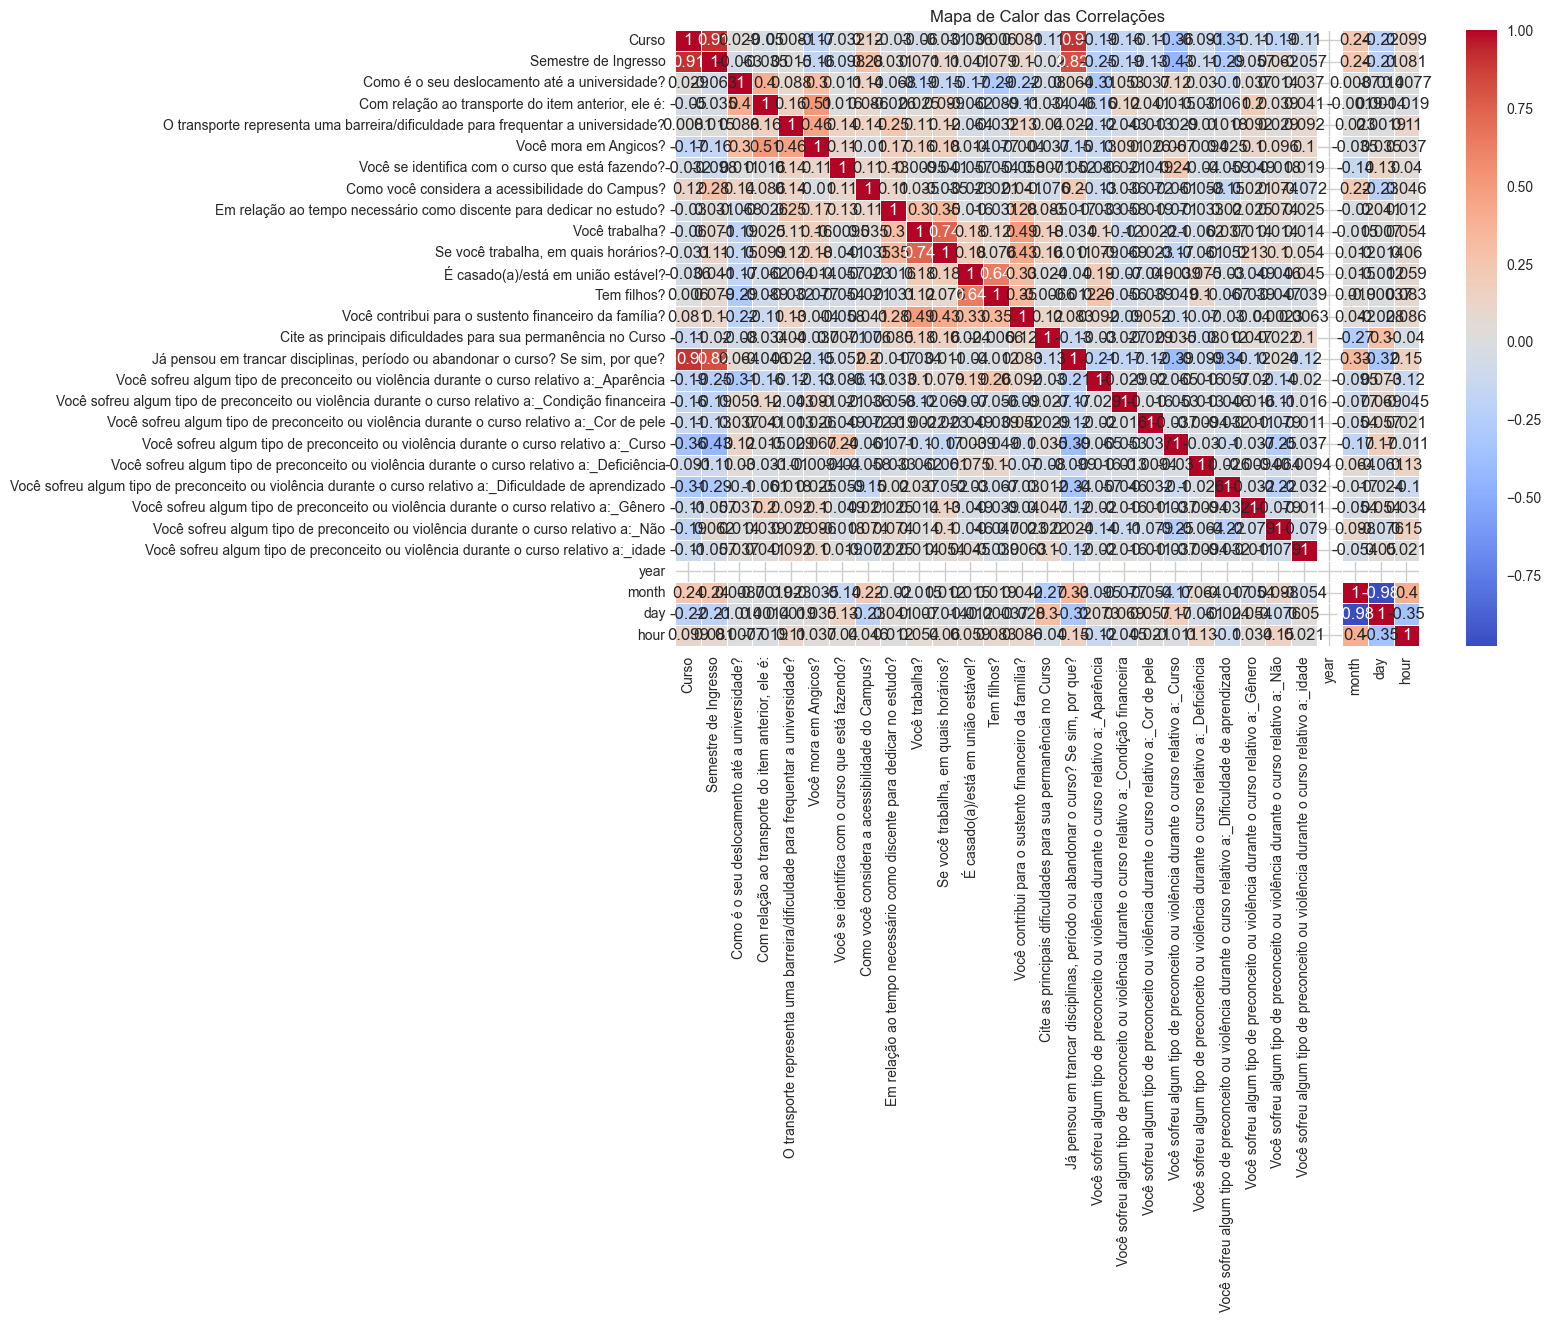

Acurácia com regularização L2: 0.975
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       0.98      0.98      0.98        46

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80



In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


if 'Carimbo de data/hora' in df.columns:
    df['Carimbo de data/hora'] = pd.to_datetime(df['Carimbo de data/hora'], errors='coerce')  
    df['year'] = df['Carimbo de data/hora'].dt.year
    df['month'] = df['Carimbo de data/hora'].dt.month
    df['day'] = df['Carimbo de data/hora'].dt.day
    df['hour'] = df['Carimbo de data/hora'].dt.hour
    df.drop('Carimbo de data/hora', axis=1, inplace=True)  

# Verificação e conversão da variável alvo para valores binários, se necessário
if df['Já pensou em trancar disciplinas, período ou abandonar o curso? Se sim, por que?'].dtype == 'object':
    le = LabelEncoder()
    df['Já pensou em trancar disciplinas, período ou abandonar o curso? Se sim, por que?'] = le.fit_transform(
        df['Já pensou em trancar disciplinas, período ou abandonar o curso? Se sim, por que?']
    )

plt.figure(figsize=(12, 8))
corr_matrix = df.corr()  # Calcula a matriz de correlação
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor das Correlações")
plt.show()

# Definição de X e y
X = df.drop('Já pensou em trancar disciplinas, período ou abandonar o curso? Se sim, por que?', axis=1)
y = df['Já pensou em trancar disciplinas, período ou abandonar o curso? Se sim, por que?']

# Imputação de valores ausentes
imputer = SimpleImputer(strategy='mean')  # ou 'median', 'most_frequent', dependendo do caso
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinamento com regularização L2 (Ridge)
model_l2 = LogisticRegression(penalty='l2', C=0.1, random_state=42)
model_l2.fit(X_train, y_train)

y_pred_l2 = model_l2.predict(X_test)
print("Acurácia com regularização L2:", accuracy_score(y_test, y_pred_l2))
print(classification_report(y_test, y_pred_l2))


In [15]:
import pandas as pd
import plotly.express as px

# Calcular a matriz de correlação
corr_matrix = df.corr()

# Gerar o mapa de calor usando Plotly
fig = px.imshow(corr_matrix,
                labels=dict(color="Correlação"),
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                color_continuous_scale='Plasma')  # Escala de cores ajustada para o gráfico
                #title="Mapa de Calor das Correlações")
                
fig.update_xaxes(showticklabels=True)
fig.update_yaxes(showticklabels=True)

# Exibir o gráfico
fig.update_layout(title_font_size=20, width=2000, height=2000)  
fig.show()


In [ ]:
final_lr_model = finalize_model(lr_model)

save_model(final_lr_model, 'modelo_evasao')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Semestre de Ingresso',
                                              'Como é o seu deslocamento até a '
                                              'universidade?',
                                              'Com relação ao transporte do '
                                              'item anterior, ele é:',
                                              'O transporte representa uma '
                                              'barreira/dificuldade para '
                                              'frequentar a universidade?',
                                              'Você mora em Angicos?',
                                              'Você se identifica com o curso '
                                              'que e...
                  TransformerWrapper(exclude=None, include=None,
       

: 

## Interpretação dos Resultados:
Diagonal escura (vermelho-escuro): A diagonal da matriz sempre terá valores de correlação iguais a 1, pois cada variável está perfeitamente correlacionada com ela mesma.

Blocos de cores mais escuras fora da diagonal: Indicariam relações mais fortes (positivas ou negativas) entre as variáveis. Se você observar várias correlações fortes (seja positivas ou negativas), isso pode indicar que algumas variáveis estão muito relacionadas entre si.

Blocos de cores claras: Valores mais próximos de zero indicam pouca ou nenhuma correlação. Isso significa que as variáveis não têm uma relação linear forte entre si.

Avaliação da qualidade dos resultados:
Correlação positiva ou negativa muito alta (próxima de ±1) pode ser um sinal de multicolinearidade, o que pode ser problemático para modelos como a regressão logística, pois significa que as variáveis podem estar transmitindo a mesma informação. Nesse caso, seria útil considerar remover ou combinar variáveis muito correlacionadas.

Correlação próxima de 0 pode ser bom para manter as variáveis em um modelo, pois elas não estão transmitindo informações redundantes.

## Próximos passos:
Se houver muitas variáveis altamente correlacionadas, considere técnicas como redução de dimensionalidade (PCA) ou remoção de variáveis correlacionadas para evitar problemas de multicolinearidade.
Você pode também observar se há variáveis com pouca ou nenhuma correlação (valores próximos de zero), o que pode ser um indicativo de que não há uma relação linear forte entre elas, e que outros tipos de interações podem estar presentes.